In [1]:
from braket.circuits import Circuit
import itertools as it
import random

def cnot_sequence(circuit_length, input_bits='00'):
    c = Circuit()
    
    # encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)
        
    # create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cnot(0, 1)
        if idx % 2 == 1: c.cnot(1, 0)
            
    return c

possible_input_bits      = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(it.product(possible_input_bits, possible_circuit_lengths))

circuit_pool             = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit = cnot_sequence(circuit_length, input_bits=input_bits)
        circuit_pool[(input_bits, circuit_length)] = circuit

def generate_circuit_batch(size):
    random_keys = random.choices(possible_keys, k=size)
    return [(key, circuit_pool[key]) for key in random_keys]

print("EXAMPLE CIRCUIT BATCH")
print("_" * 24)
for key, circuit in generate_circuit_batch(5):
    print()
    print("input_bits={}, length={}".format(*key))
    print("-" * 24)
    print(circuit)
    print("_" * 24)

EXAMPLE CIRCUIT BATCH
________________________

input_bits=11, length=2
------------------------
T  : │  0  │  1  │  2  │
      ┌───┐       ┌───┐ 
q0 : ─┤ X ├───●───┤ X ├─
      └───┘   │   └─┬─┘ 
      ┌───┐ ┌─┴─┐   │   
q1 : ─┤ X ├─┤ X ├───●───
      └───┘ └───┘       
T  : │  0  │  1  │  2  │
________________________

input_bits=11, length=3
------------------------
T  : │  0  │  1  │  2  │  3  │
      ┌───┐       ┌───┐       
q0 : ─┤ X ├───●───┤ X ├───●───
      └───┘   │   └─┬─┘   │   
      ┌───┐ ┌─┴─┐   │   ┌─┴─┐ 
q1 : ─┤ X ├─┤ X ├───●───┤ X ├─
      └───┘ └───┘       └───┘ 
T  : │  0  │  1  │  2  │  3  │
________________________

input_bits=10, length=4
------------------------
T  : │  0  │  1  │  2  │  3  │  4  │
      ┌───┐       ┌───┐       ┌───┐ 
q0 : ─┤ X ├───●───┤ X ├───●───┤ X ├─
      └───┘   │   └─┬─┘   │   └─┬─┘ 
            ┌─┴─┐   │   ┌─┴─┐   │   
q1 : ───────┤ X ├───●───┤ X ├───●───
            └───┘       └───┘       
T  : │  0  │  1  │  2  │  3  │  4  │
_________

In [5]:
# The following is just a convenient little timer for things that take a while in the code below.
# I snipped it from https://medium.com/@DahlitzF/how-to-create-your-own-timing-context-manager-in-python-a0e944b48cf8

from time import time

class Timer:
    def __init__(self, description):
        self.description = description
    def __enter__(self):
        self.start = time()
    def __exit__(self, type, value, traceback):
        self.end = time()
        print(f"complete: {self.end - self.start:.3f}")

In [6]:
from braket.circuits import Circuit, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice


In [7]:
# On with the actual code...

aws_simulator = AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/sv1")
#ionq = AwsDevice("arn:aws:braket:us-east-1::device/qpu/ionq/Harmony")
ionq = AwsDevice("arn:aws:braket:us-east-1::device/qpu/ionq/Aria-1")
# s3_folder = ("amazon-braket-quasimodo-840eb696707f", "yuval_mwe_preliminary")
s3_folder = ("amazon-braket-eng-dev", "yuval_mwe_preliminary")


reference_table = {}

for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        
        circuit_to_simulate = circuit_pool[(input_bits, circuit_length)]
        print(f"Starting job: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
        
        with Timer("AWS simulator"):
            # First create the task for Amazon's circuit simulator.
            # Note that the number of shots is irrelevant here;
            # I want the simulated measurement probabilities only.
            task = aws_simulator.run(circuit_to_simulate, s3_folder, shots=1)
            
            # Now I can extract the measurement probabilities.
            # This is a dictionary of the form {correct_output: 1}.
            # The useful information is therefore the key, not the value.
            result = task.result().measurement_probabilities
            correct_output = list(result.keys())[0]
            
            # I now store the correct output in the reference table.
            reference_table[(input_bits, circuit_length)] = correct_output
     

Starting job: input_bits=00, circuit_length=1... complete: 3.011
Starting job: input_bits=00, circuit_length=2... complete: 2.576
Starting job: input_bits=00, circuit_length=3... complete: 2.721
Starting job: input_bits=00, circuit_length=4... complete: 2.695
Starting job: input_bits=00, circuit_length=5... complete: 2.663
Starting job: input_bits=00, circuit_length=6... complete: 2.759
Starting job: input_bits=01, circuit_length=1... complete: 2.699
Starting job: input_bits=01, circuit_length=2... complete: 2.777
Starting job: input_bits=01, circuit_length=3... complete: 2.653
Starting job: input_bits=01, circuit_length=4... complete: 4.678
Starting job: input_bits=01, circuit_length=5... complete: 2.620
Starting job: input_bits=01, circuit_length=6... complete: 2.711
Starting job: input_bits=10, circuit_length=1... complete: 2.755
Starting job: input_bits=10, circuit_length=2... complete: 2.621
Starting job: input_bits=10, circuit_length=3... complete: 2.586
Starting job: input_bits=

In [8]:
for input_bits in possible_input_bits:
    reference = [input_bits] + [reference_table[(input_bits, l)] for l in possible_circuit_lengths]
    print("{} | {} {} {} {} {} {}".format(*reference))


00 | 00 00 00 00 00 00
01 | 01 11 10 10 11 01
10 | 11 01 01 11 10 10
11 | 10 10 11 01 01 11


In [9]:
#test_batch = generate_circuit_batch(1000)
test_batch = generate_circuit_batch(100)
tasks = [ionq.run(circuit, s3_folder, shots=100) for key, circuit in test_batch]
#tasks = [ionq.run(circuit, s3_folder, shots=1000) for key, circuit in test_batch]
task_id = [t.id for t in tasks]
print(task_id)
     

['arn:aws:braket:us-east-1:835581428919:quantum-task/4dba09a5-273f-4d85-a9ce-1851257f4a37', 'arn:aws:braket:us-east-1:835581428919:quantum-task/c195554b-bfee-4512-acb3-923c60c0f6d0', 'arn:aws:braket:us-east-1:835581428919:quantum-task/b584f81f-71a1-4d31-b49f-c1cf6e0fef22', 'arn:aws:braket:us-east-1:835581428919:quantum-task/230ccce7-1f0f-4af3-bb20-2e63aeb62359', 'arn:aws:braket:us-east-1:835581428919:quantum-task/c4a024e3-8bc4-4c7d-af41-aadf20a31374', 'arn:aws:braket:us-east-1:835581428919:quantum-task/b13800fa-d2f0-47ae-b00e-a80187dda729', 'arn:aws:braket:us-east-1:835581428919:quantum-task/4c4fcef0-f112-4b0a-9ed7-72ca147f54a0', 'arn:aws:braket:us-east-1:835581428919:quantum-task/ca2e5968-e539-46aa-b525-715ad87689f0', 'arn:aws:braket:us-east-1:835581428919:quantum-task/14fd30c0-a65d-41a3-94fc-6adf9705ab88', 'arn:aws:braket:us-east-1:835581428919:quantum-task/048b85de-db86-48ac-9613-16bb3dc52f97', 'arn:aws:braket:us-east-1:835581428919:quantum-task/80fe8eef-6d04-4209-bd93-bbefe6eaca29'

In [10]:
state_list = []

with Timer("Fetching the state takes super long..."):
    for k in range(len(tasks)):
        state = tasks[k].state()
        state_list += [state]
        print(f"Task {k:>3}: {state:<10}", end="\r")
    print("State fetch", end=" ")

number_of_tasks_still_queued = sum(1 if state_list[k] == 'QUEUED' else 0
                                   for k in range(len(state_list)))

if number_of_tasks_still_queued == 0:
    print("All tasks complete!")
else:
    print(f"Still waiting on {number_of_tasks_still_queued} tasks.")

State fetch complete: 18.905
Still waiting on 9 tasks.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = []

for idx in range(len(tasks)):
    print(idx)
    #print('DEBUG')
    the_task   = tasks[idx]
    #print('DEBUG')
    task_id    = the_task.id
    #print('DEBUG')
    the_result = the_task.result()
    #print('DEBUG')
    
    start_time   = pd.to_datetime(the_result.task_metadata.createdAt)
    end_time     = pd.to_datetime(the_result.task_metadata.endedAt)
    elapsed_time = end_time - start_time
    
    batch_member   = test_batch[idx]
    circuit_key    = batch_member[0]
    input_bits     = circuit_key[0]
    circuit_length = circuit_key[1]

    
    measurement_probabilities = the_result.measurement_probabilities
    correct_output            = reference_table[circuit_key]
    success_probability       = measurement_probabilities[correct_output]
    
    data.append((task_id,
                 input_bits,
                 circuit_length,
                 start_time,
                 end_time,
                 elapsed_time,
                 success_probability))

data = pd.DataFrame(data, columns=['id_string',
                                   'input_bits',
                                   'circuit_length',
                                   'start_time',
                                   'end_time',
                                   'elapsed_time',
                                   'success_probability'])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [12]:
data

,id_string,input_bits,circuit_length,start_time,end_time,elapsed_time,success_probability
0,arn:aws:braket:us-east-1:835581428919:quantum-...,01,6,2024-03-14 22:43:55.840000+00:00,2024-03-14 22:45:15.357000+00:00,0 days 00:01:19.517000,1.00
1,arn:aws:braket:us-east-1:835581428919:quantum-...,01,2,2024-03-14 22:43:56.069000+00:00,2024-03-14 22:45:15.997000+00:00,0 days 00:01:19.928000,0.99
2,arn:aws:braket:us-east-1:835581428919:quantum-...,11,6,2024-03-14 22:43:56.269000+00:00,2024-03-14 22:45:47.799000+00:00,0 days 00:01:51.530000,0.99
3,arn:aws:braket:us-east-1:835581428919:quantum-...,01,6,2024-03-14 22:43:56.472000+00:00,2024-03-14 22:45:48.369000+00:00,0 days 00:01:51.897000,0.99
4,arn:aws:braket:us-east-1:835581428919:quantum-...,10,6,2024-03-14 22:43:56.707000+00:00,2024-03-14 22:45:49.011000+00:00,0 days 00:01:52.304000,1.00
...,...,...,...,...,...,...,...
95,arn:aws:braket:us-east-1:835581428919:quantum-...,10,1,2024-03-14 22:44:17.330000+00:00,2024-03-14 22:52:32.061000+00:00,0 days 00:08:14.731000,0.99
96,arn:aws:braket:us-east-1:835581428919:quantum-...,00,2,2024-03-14 22:44:17.545000+00:00,2024-03-14 22:52:32.646000+00:00,0 days 00:08:15.101000,1.00
97,arn:aws:braket:us-east-1:835581428919:quantum-...,01,1,2024-03-14 22:44:17.756000+00:00,2024-03-14 22:52:33.222000+00:00,0 days 00:08:15.466000,0.99
98,arn:aws:braket:us-east-1:835581428919:quantum-...,11,1,2024-03-14 22:44:17.963000+00:00,2024-03-14 22:52:33.744000+00:00,0 days 00:08:15.781000,0.99


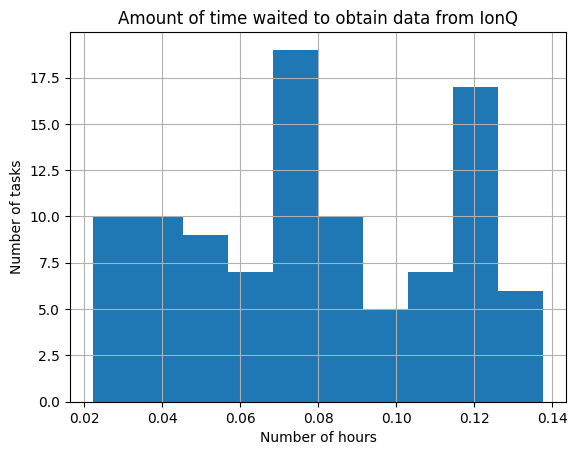

In [13]:
data['elapsed_time_hours'] = data['elapsed_time'].dt.total_seconds() / 3600
data['elapsed_time_hours'].hist()
plt.xlabel("Number of hours")
plt.ylabel("Number of tasks")
plt.title("Amount of time waited to obtain data from IonQ")
plt.show()
     


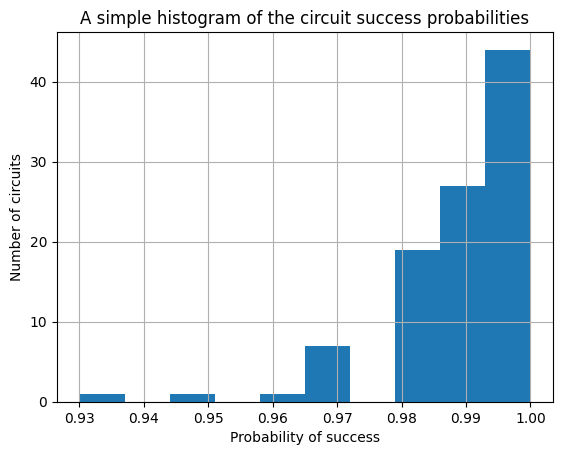

In [14]:
data['success_probability'].hist()
plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("A simple histogram of the circuit success probabilities")
plt.show()
     


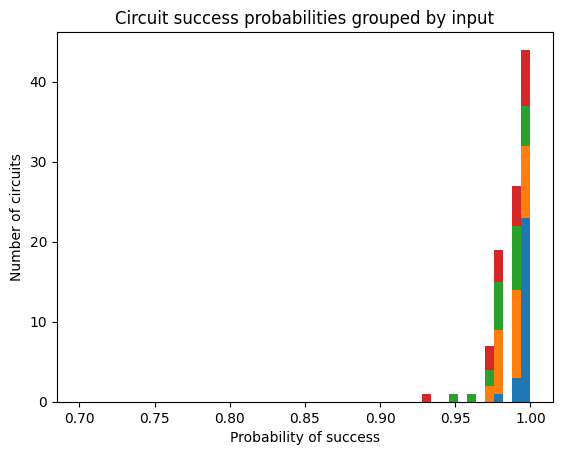

In [15]:
plt.hist([df["success_probability"] for input_bits, df in data.groupby("input_bits")],
          bins=50, range=(0.7, 1.0), stacked=True)

plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("Circuit success probabilities grouped by input")
plt.show()

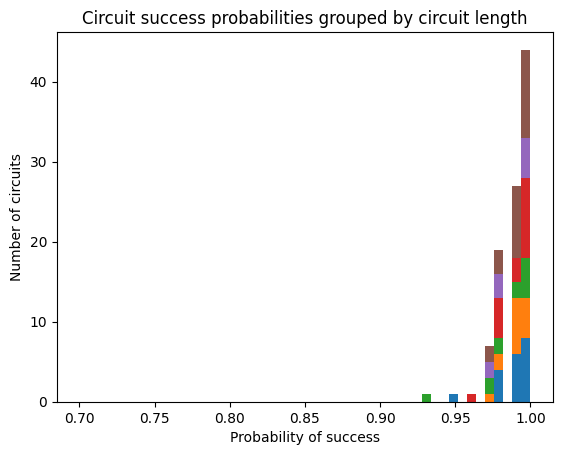

In [16]:
plt.hist([df["success_probability"] for input_bits, df in data.groupby("circuit_length")],
          bins=50, range=(0.7, 1.0), stacked=True)

plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("Circuit success probabilities grouped by circuit length")
plt.show()

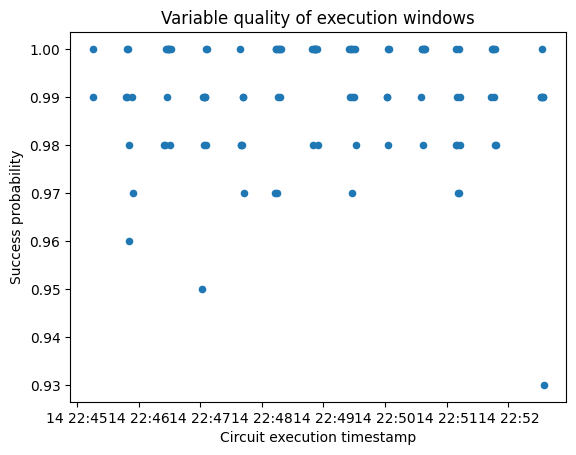

In [17]:
data.plot.scatter(x="end_time", y="success_probability")
plt.xlabel("Circuit execution timestamp")
plt.ylabel("Success probability")
plt.title("Variable quality of execution windows")
plt.show()
     

In [18]:
!pip install seaborn
     

In [19]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
sns.violinplot(data=data, x='circuit_length', y='success_probability')
plt.xlabel("Circuit Length")
plt.ylabel("Success Probability")
plt.title("Performance for random CNOT test")
plt.show()

In [ ]:
data['good?'] = data['success_probability'] > (90 + (7 - data['circuit_length']))/100
sns.violinplot(data=data, x='circuit_length', y='success_probability', hue='good?')
plt.xlabel("Circuit Length")
plt.ylabel("Success Probability")
plt.title("Performance for random CNOT test")
plt.show()
     

In [ ]:
sns.kdeplot(data=data, x='end_time', hue='good?', multiple='fill')
plt.xlabel("Circuit Execution Timestamp")
plt.xticks(rotation=-90)
plt.title("Simple Execution Window Classification")
plt.show()
     

In [ ]:
data['execution_window'] = 'discarded'

end_A   = pd.Timestamp(year=2023, month=1, day=29, hour=22, tz='UTC')
start_B = pd.Timestamp(year=2023, month=1, day=30, hour=2, tz='UTC')
end_B   = pd.Timestamp(year=2023, month=1, day=30, hour=4, tz='UTC')

data.loc[data['end_time'] < end_A, 'execution_window'] = 'A'
data.loc[(data['end_time'] >= start_B) & (data['end_time'] < end_B), 'execution_window'] = 'B'

sns.lmplot(data=data, x='circuit_length', y='success_probability', hue='execution_window')
plt.xlabel("Circuit Length")
plt.ylabel("Success Probability")
plt.title("Performance classified by execution window")
plt.show()

In [ ]:
g = sns.kdeplot(data=data.groupby('circuit_length').get_group(6),
                x='success_probability', hue='execution_window', multiple='fill')
sns.move_legend(g, 'upper left', title='Execution Window')
plt.xlabel('Success Probability')
plt.xlim(0.7, 1.0)
plt.title("Execution window quality check")
plt.show()
     

In [ ]:
sns.histplot(data=data, x='end_time', bins=100)
plt.xticks(rotation=-90)
plt.xlabel("Execution timestamp")
plt.title("Distribution of execution times for a set of 1000 circuits")
plt.show()
     

In [ ]:
for id_str in task_id:
    print(id_str)
     

In [ ]:
for key, circuit in test_batch:
    print(key)
     

In [ ]:
len(tasks)
